In [1]:
from multi_nutrient_model_ext import mass_and_energy_constraints, AMINO_ACIDS, protein_composition
import scipy.optimize as opt
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## Setup Model Parameters

In [2]:
# ATP per O2 (5 per O2, considering P/O ratio)
PO2 = 5.0
# Whole body oxygen consumption rate ~ 2000 nmol/min/gBW
vO2 = 2000
# ATP production rate
vATP = PO2 * vO2

print(f"ATP production rate: {vATP:.0f} nmol/min/gBW")

ATP production rate: 10000 nmol/min/gBW


## Solve for Steady State Fluxes

In [3]:
# Total number of fluxes: 11 (core) + 2 (protein) + 19 (AA ox) + 2 (AA GNG) + 6 (N recycling) + 1 (Ala->Lac) = 41
n_fluxes = 11 + 2 + 19 + 2 + 6 + 1 
print(f"Total number of fluxes: {n_fluxes}")

# Set initial guess
# Core fluxes (11): vL, vG, vF, vK, vGL, vFK, vLG, v0, vLip, vReest, vCO2
# Protein (2): vPD, vPS
# AA oxidation (19): one per amino acid
# AA GNG (2): v_GNG_Gln, v_GNG_Ala
# N recycling (6): vN_Glu_Gln, vN_Asp_Gln, vN_Pro_Gln, vN_Gly_Gln, vN_Lac_Gln, vN_Lac_Ala
# Ala->Lac (1): v_Ala_Lac

v0 = np.ones(n_fluxes) * 0.1
print(f"Initial guess shape: {v0.shape}")


Total number of fluxes: 41
Initial guess shape: (41,)


In [4]:
# Solve for steady state fluxes using least_squares with bounds
# Set lower bound to 0 for all fluxes (non-negativity constraint)
lower_bounds = np.zeros(n_fluxes)
upper_bounds = np.full(n_fluxes, np.inf)

# Use least_squares which supports bounds
res = opt.least_squares(
    mass_and_energy_constraints, 
    v0, 
    bounds=(lower_bounds, upper_bounds),
    max_nfev=1000,
    ftol=1e-12,
    xtol=1e-12
)

solution = res.x
residuals_norm = np.linalg.norm(res.fun)

print("Solver converged:", res.success)
print(f"Status: {res.message}")
print(f"Residual norm: {residuals_norm:.2e}")
print(f"Max residual: {np.abs(res.fun).max():.2e}")
print(f"Number of function evaluations: {res.nfev}")


Solver converged: True
Status: `gtol` termination condition is satisfied.
Residual norm: 1.63e-03
Max residual: 8.81e-04
Number of function evaluations: 18


## Constrained-Based Optimization for True Steady State

The least squares solution above minimizes the residuals but doesn't guarantee exact steady state (dxdt = 0). 
We'll use constrained optimization to find the flux vector closest to the least squares solution that exactly satisfies the **core mass balance constraints**:

**Core constraints enforced (30 total):**
- Metabolite mass balances: dLdt, dGdt, dFdt, dKdt (4)
- Amino acid mass balances: dAAdt for 19 amino acids (19)
- Carbon balance: dCO2 (1)
- Nitrogen balance: dN (1)
- Energy balance: dE (1)
- **Minimal oxidation constraints: dAsp_ox_min, dGlu_ox_min, dGly_ox_min, dPro_ox_min (4)**

**Minimal oxidation constraints:**
- `dAsp_ox_min`: Aspartate oxidation ≥ 1% of aspartate from protein degradation
- `dGlu_ox_min`: Glutamate oxidation ≥ 1% of glutamate from protein degradation
- `dGly_ox_min`: Glycine oxidation ≥ 1% of glycine from protein degradation
- `dPro_ox_min`: Proline oxidation ≥ 1% of proline from protein degradation

**Additional constraints NOT enforced:**
- Appearance rate constraints (dFG, dFL, dFF, dFK, dFAL, dFGLN, dPD, dPS)
- GNG ratio constraint (dGNG)
- Re-esterification constraint (dReest)
- NEAA circulatory flux constraints (dFGLU, dFPRO, dFGLY, dFASP)
- Empirical constraints (dAL, dAmonia, dCO2_carbo, dGNG_Gln_min, dGNG_Ala_min)

In [5]:
from scipy.optimize import minimize

# Define objective: minimize distance from least squares solution
def objective_distance(v):
    """Minimize Euclidean distance from least squares solution"""
    return np.sum((v - solution)**2)

# Define equality constraints: only core mass balances (dxdt = 0)
# Excludes additional constraints like appearance rates, GNG ratios, etc.
def constraint_mass_balance(v):
    """
    Core mass balance constraints must equal zero at steady state:
    - dLdt, dGdt, dFdt, dKdt (4 metabolites)
    - dAAdt_{aa} (19 amino acids)
    - dCO2 (carbon balance)
    - dN (nitrogen balance)
    - dE (energy balance)
    - Minimal oxidation constraints for Asp, Glu, Gly, Pro (4)
    Total: 30 core constraints
    """
    # Get constraints as a dictionary
    constraints_dict = mass_and_energy_constraints(v, return_dict=True)
    
    # Extract only the core mass balance constraints
    core_constraints = [
        constraints_dict['dLdt'],
        constraints_dict['dGdt'],
        constraints_dict['dFdt'],
        constraints_dict['dKdt'],
    ]
    
    # Add amino acid mass balances
    for aa in AMINO_ACIDS:
        core_constraints.append(constraints_dict[f'dAAdt_{aa}'])
    
    # Add CO2, nitrogen, and energy balances
    core_constraints.extend([
        constraints_dict['dCO2'],
        constraints_dict['dN'],
        constraints_dict['dE'],
    ])    

    # Minimal oxidation constraints for aspartate, glutamate, glycine, and proline
    core_constraints.append(constraints_dict['dAsp_ox_min'])
    core_constraints.append(constraints_dict['dGlu_ox_min'])
    core_constraints.append(constraints_dict['dGly_ox_min'])
    core_constraints.append(constraints_dict['dPro_ox_min'])

    return np.array(core_constraints)


# Set up the optimization problem
constraints = {
    'type': 'eq',
    'fun': constraint_mass_balance
}

# Bounds: all fluxes must be non-negative
bounds_opt = [(0, None) for _ in range(n_fluxes)]

# Initial guess: use least squares solution
x0_opt = solution.copy()

# Solve constrained optimization problem
print("Running constrained optimization to find exact steady state...")
print("This minimizes distance from least squares solution subject to dxdt = 0\n")

result_opt = minimize(
    objective_distance,
    x0_opt,
    method='SLSQP',  # Sequential Least Squares Programming
    bounds=bounds_opt,
    constraints=constraints,
    options={'maxiter': 10000, 'ftol': 1e-12}
)

print("Optimization converged:", result_opt.success)
print(f"Status: {result_opt.message}")
print(f"Objective value (distance^2): {result_opt.fun:.2e}")
print(f"Distance from LS solution: {np.sqrt(result_opt.fun):.2e}")
print(f"Number of iterations: {result_opt.nit}")

# Check constraint satisfaction
residuals_opt = constraint_mass_balance(result_opt.x)
residuals_norm_opt = np.linalg.norm(residuals_opt)
print(f"\nConstraint satisfaction:")
print(f"  Residual norm: {residuals_norm_opt:.2e}")
print(f"  Max residual: {np.abs(residuals_opt).max():.2e}")

# Store the constrained solution
solution_constrained = result_opt.x


Running constrained optimization to find exact steady state...
This minimizes distance from least squares solution subject to dxdt = 0

Optimization converged: True
Status: Optimization terminated successfully
Objective value (distance^2): 1.09e-06
Distance from LS solution: 1.04e-03
Number of iterations: 2

Constraint satisfaction:
  Residual norm: 1.09e-15
  Max residual: 8.30e-16


### Compare Least Squares vs Constrained Solutions

In [6]:
# Extract least squares solution fluxes
vL, vG, vF, vK, vGL, vFK, vLG, v0, vLip, vReest, vCO2 = solution[0:11]
vPD, vPS = solution[11:13]
vOx = {aa: solution[13 + i] for i, aa in enumerate(AMINO_ACIDS)}
v_GNG_Gln = solution[32]
v_GNG_Ala = solution[33]    

# Individual nitrogen recycling fluxes
vN_Glu_Gln = solution[34]
vN_Asp_Gln = solution[35]
vN_Pro_Gln = solution[36]
vN_Gly_Gln = solution[37]
vN_Lac_Gln = solution[38]
vN_Lac_Ala = solution[39]
v_Ala_Lac = solution[40]

# Compute total nitrogen recycling (Note: vN_Lac_Gln consumes 2N per flux unit)
vN_total = vN_Glu_Gln + vN_Asp_Gln + vN_Pro_Gln + vN_Gly_Gln + vN_Lac_Ala + 2*vN_Lac_Gln

# Extract constrained solution fluxes
vL_c, vG_c, vF_c, vK_c, vGL_c, vFK_c, vLG_c, v0_c, vLip_c, vReest_c, vCO2_c = solution_constrained[0:11]
vPD_c, vPS_c = solution_constrained[11:13]
vOx_c = {aa: solution_constrained[13 + i] for i, aa in enumerate(AMINO_ACIDS)}
v_GNG_Gln_c = solution_constrained[32]
v_GNG_Ala_c = solution_constrained[33]

# Individual nitrogen recycling fluxes
vN_Glu_Gln_c = solution_constrained[34]
vN_Asp_Gln_c = solution_constrained[35]
vN_Pro_Gln_c = solution_constrained[36]
vN_Gly_Gln_c = solution_constrained[37]
vN_Lac_Gln_c = solution_constrained[38]
vN_Lac_Ala_c = solution_constrained[39]
v_Ala_Lac_c = solution_constrained[40]

# Compute total nitrogen recycling (Note: vN_Lac_Gln consumes 2N per flux unit)
vN_total_c = vN_Glu_Gln_c + vN_Asp_Gln_c + vN_Pro_Gln_c + vN_Gly_Gln_c + vN_Lac_Ala_c + 2*vN_Lac_Gln_c

# Create comparison dataframe for key fluxes
flux_comparison = pd.DataFrame({
    'Flux': ['vL', 'vG', 'vF', 'vK', 'vGL', 'vFK', 'vLG', 'v0', 'vLip', 'vReest', 'vCO2',
             'vPD', 'vPS', 'v_GNG_Gln', 'v_GNG_Ala', 'vN_total', 'v_Ala_Lac',
             'vN_Glu_Gln', 'vN_Asp_Gln', 'vN_Pro_Gln', 'vN_Gly_Gln', 'vN_Lac_Gln', 'vN_Lac_Ala'],
    'Least Squares': [vL, vG, vF, vK, vGL, vFK, vLG, v0, vLip, vReest, vCO2,
                      vPD, vPS, v_GNG_Gln, v_GNG_Ala, vN_total, v_Ala_Lac,
                      vN_Glu_Gln, vN_Asp_Gln, vN_Pro_Gln, vN_Gly_Gln, vN_Lac_Gln, vN_Lac_Ala],
    'Constrained': [vL_c, vG_c, vF_c, vK_c, vGL_c, vFK_c, vLG_c, v0_c, vLip_c, vReest_c, vCO2_c,
                    vPD_c, vPS_c, v_GNG_Gln_c, v_GNG_Ala_c, vN_total_c, v_Ala_Lac_c,
                    vN_Glu_Gln_c, vN_Asp_Gln_c, vN_Pro_Gln_c, vN_Gly_Gln_c, vN_Lac_Gln_c, vN_Lac_Ala_c]
})

# Calculate differences
flux_comparison['Absolute Diff'] = flux_comparison['Constrained'] - flux_comparison['Least Squares']
flux_comparison['Relative Diff (%)'] = 100 * flux_comparison['Absolute Diff'] / (flux_comparison['Least Squares'] + 1e-10)

print("Comparison of Least Squares vs Constrained Optimization Solutions:\n")
print(flux_comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print(f"\n\nMaximum absolute difference: {flux_comparison['Absolute Diff'].abs().max():.4e}")
print(f"Maximum relative difference: {flux_comparison['Relative Diff (%)'].abs().max():.2f}%")
print(f"Mean absolute difference: {flux_comparison['Absolute Diff'].abs().mean():.4e}")
print(f"Mean relative difference: {flux_comparison['Relative Diff (%)'].abs().mean():.2f}%")

Comparison of Least Squares vs Constrained Optimization Solutions:

      Flux  Least Squares  Constrained  Absolute Diff  Relative Diff (%)
        vL         0.0108       0.0106        -0.0002            -2.0113
        vG         0.0005       0.0002        -0.0003           -57.7478
        vF         0.0055       0.0054        -0.0001            -1.6069
        vK         0.0040       0.0040         0.0000             0.1746
       vGL         0.0097       0.0098         0.0001             1.4314
       vFK         0.0010       0.0010        -0.0000            -0.1678
       vLG         0.0033       0.0032        -0.0002            -4.5199
        v0         0.0038       0.0041         0.0003             7.8988
      vLip         0.0067       0.0067        -0.0000            -0.3476
    vReest         0.0045       0.0045         0.0000             0.5152
      vCO2         0.1621       0.1620        -0.0000            -0.0209
       vPD         0.0172       0.0173         0.0000   

In [7]:
# Compare amino acid oxidation fluxes
aa_comparison = pd.DataFrame({
    'Amino Acid': AMINO_ACIDS,
    'Least Squares': [vOx[aa] for aa in AMINO_ACIDS],
    'Constrained': [vOx_c[aa] for aa in AMINO_ACIDS],
})

aa_comparison['Absolute Diff'] = aa_comparison['Constrained'] - aa_comparison['Least Squares']
aa_comparison['Relative Diff (%)'] = 100 * aa_comparison['Absolute Diff'] / (aa_comparison['Least Squares'] + 1e-10)

print("\nAmino Acid Oxidation Fluxes Comparison:\n")
print(aa_comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print(f"\n\nAA Max absolute difference: {aa_comparison['Absolute Diff'].abs().max():.4e}")
print(f"AA Max relative difference: {aa_comparison['Relative Diff (%)'].abs().max():.2f}%")


Amino Acid Oxidation Fluxes Comparison:

Amino Acid  Least Squares  Constrained  Absolute Diff  Relative Diff (%)
       Ala         0.0007       0.0006        -0.0001           -14.1011
       Arg         0.0005       0.0003        -0.0002           -41.0214
       Asn         0.0003       0.0002        -0.0001           -17.8134
       Asp         0.0000       0.0000         0.0000         32635.3174
       Cys         0.0001       0.0001         0.0000            21.1469
       Gln         0.0012       0.0010        -0.0003           -22.2627
       Glu         0.0000       0.0000         0.0000         29417.2385
       Gly         0.0000       0.0000        -0.0000           -45.5003
       His         0.0002       0.0001        -0.0001           -37.7384
       Ile         0.0001       0.0003         0.0002           206.3232
       Leu         0.0003       0.0005         0.0002            51.7151
       Lys         0.0004       0.0004         0.0000            10.7982
       Me

### Visualize Differences Between Solutions

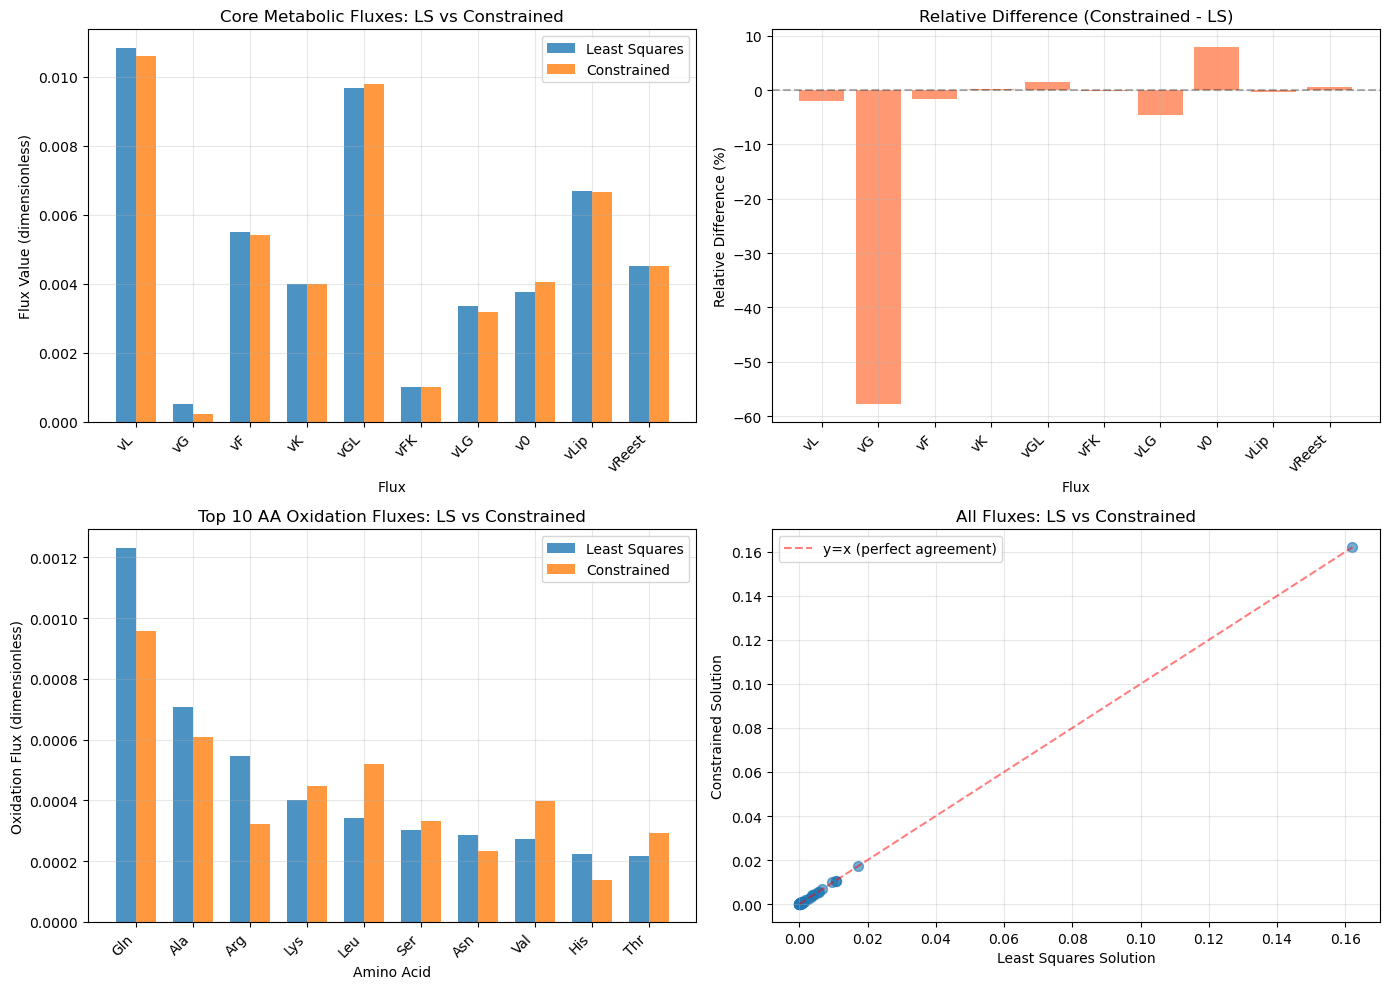


Visual comparison shows that solutions are very similar


In [8]:
import matplotlib.pyplot as plt

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Core metabolic fluxes comparison
ax1 = axes[0, 0]
core_fluxes = ['vL', 'vG', 'vF', 'vK', 'vGL', 'vFK', 'vLG', 'v0', 'vLip', 'vReest']
core_data = flux_comparison[flux_comparison['Flux'].isin(core_fluxes)]

x_pos = np.arange(len(core_data))
width = 0.35

ax1.bar(x_pos - width/2, core_data['Least Squares'], width, label='Least Squares', alpha=0.8)
ax1.bar(x_pos + width/2, core_data['Constrained'], width, label='Constrained', alpha=0.8)
ax1.set_xlabel('Flux')
ax1.set_ylabel('Flux Value (dimensionless)')
ax1.set_title('Core Metabolic Fluxes: LS vs Constrained')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(core_data['Flux'], rotation=45, ha='right')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Relative differences for core fluxes
ax2 = axes[0, 1]
ax2.bar(x_pos, core_data['Relative Diff (%)'], alpha=0.8, color='coral')
ax2.set_xlabel('Flux')
ax2.set_ylabel('Relative Difference (%)')
ax2.set_title('Relative Difference (Constrained - LS)')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(core_data['Flux'], rotation=45, ha='right')
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.grid(alpha=0.3)

# 3. Top 10 amino acid oxidation fluxes
ax3 = axes[1, 0]
aa_sorted = aa_comparison.nlargest(10, 'Least Squares')
x_pos_aa = np.arange(len(aa_sorted))

ax3.bar(x_pos_aa - width/2, aa_sorted['Least Squares'], width, label='Least Squares', alpha=0.8)
ax3.bar(x_pos_aa + width/2, aa_sorted['Constrained'], width, label='Constrained', alpha=0.8)
ax3.set_xlabel('Amino Acid')
ax3.set_ylabel('Oxidation Flux (dimensionless)')
ax3.set_title('Top 10 AA Oxidation Fluxes: LS vs Constrained')
ax3.set_xticks(x_pos_aa)
ax3.set_xticklabels(aa_sorted['Amino Acid'], rotation=45, ha='right')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Overall flux distribution comparison
ax4 = axes[1, 1]
all_ls = np.concatenate([flux_comparison['Least Squares'].values, 
                         aa_comparison['Least Squares'].values])
all_const = np.concatenate([flux_comparison['Constrained'].values,
                           aa_comparison['Constrained'].values])

ax4.scatter(all_ls, all_const, alpha=0.6, s=50)
max_val = max(all_ls.max(), all_const.max())
ax4.plot([0, max_val], [0, max_val], 'r--', label='y=x (perfect agreement)', alpha=0.5)
ax4.set_xlabel('Least Squares Solution')
ax4.set_ylabel('Constrained Solution')
ax4.set_title('All Fluxes: LS vs Constrained')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nVisual comparison shows that solutions are {'very similar' if np.abs(all_ls - all_const).max() < 0.01 else 'different'}")

### Update Solution for Downstream Analysis

Use the constrained solution (which exactly satisfies dxdt=0) for all subsequent analyses:

In [9]:
# Update the solution to use the constrained optimization result
# This ensures all downstream analyses use the exact steady state
solution = solution_constrained.copy()

# Re-extract fluxes (this updates the variables used in later cells)
vL, vG, vF, vK, vGL, vFK, vLG, v0, vLip, vReest, vCO2 = solution[0:11]
vPD, vPS = solution[11:13]
vOx = {aa: solution[13 + i] for i, aa in enumerate(AMINO_ACIDS)}
v_GNG_Gln = solution[32]
v_GNG_Ala = solution[33]

# Individual nitrogen recycling fluxes
vN_Glu_Gln = solution[34]
vN_Asp_Gln = solution[35]
vN_Pro_Gln = solution[36]
vN_Gly_Gln = solution[37]
vN_Lac_Gln = solution[38]
vN_Lac_Ala = solution[39]
v_Ala_Lac = solution[40]

# Compute total nitrogen recycling (Note: vN_Lac_Gln consumes 2N per flux unit)
vN_total = vN_Glu_Gln + vN_Asp_Gln + vN_Pro_Gln + vN_Gly_Gln + vN_Lac_Ala + 2*vN_Lac_Gln

print("Solution updated to use constrained optimization result.")
print("All downstream analyses will use the exact steady state (dxdt = 0).")

Solution updated to use constrained optimization result.
All downstream analyses will use the exact steady state (dxdt = 0).


## Extract and Display Fluxes

In [10]:
# Extract fluxes
vL, vG, vF, vK, vGL, vFK, vLG, v0, vLip, vReest, vCO2 = solution[0:11]
vPD, vPS = solution[11:13]

# Amino acid oxidation fluxes
vOx = {aa: solution[13 + i] for i, aa in enumerate(AMINO_ACIDS)}

# Amino acid GNG fluxes
v_GNG_Gln = solution[32]
v_GNG_Ala = solution[33]

# Individual nitrogen recycling fluxes
vN_Glu_Gln = solution[34]
vN_Asp_Gln = solution[35]
vN_Pro_Gln = solution[36]
vN_Gly_Gln = solution[37]
vN_Lac_Gln = solution[38]
vN_Lac_Ala = solution[39]
v_Ala_Lac = solution[40]

# Compute total nitrogen recycling (Note: vN_Lac_Gln consumes 2N per flux unit)
vN_total = vN_Glu_Gln + vN_Asp_Gln + vN_Pro_Gln + vN_Gly_Gln + vN_Lac_Ala + 2*vN_Lac_Gln

print("Core Metabolic Fluxes (dimensionless):")
print(f"  vL (Lactate ox):        {vL:.4f}")
print(f"  vG (Glucose ox):        {vG:.4f}")
print(f"  vF (Fatty acid ox):     {vF:.4f}")
print(f"  vK (Ketone ox):         {vK:.4f}")
print(f"  vGL (Glycolysis):       {vGL:.4f}")
print(f"  vFK (Ketogenesis):      {vFK:.4f}")
print(f"  vLG (GNG from lactate): {vLG:.4f}")
print(f"  v0 (Glycogenolysis):    {v0:.4f}")
print(f"  vLip (Lipolysis):       {vLip:.4f}")
print(f"  vReest (Re-esterif):    {vReest:.4f}")
print(f"  vCO2 (CO2 production):  {vCO2:.4f}")
print(f"\nProtein Turnover:")
print(f"  vPD (Degradation):      {vPD:.4f}")
print(f"  vPS (Synthesis):        {vPS:.4f}")
print(f"\nAmino Acid Metabolism:")
print(f"  v_GNG_Gln:              {v_GNG_Gln:.4f}")
print(f"  v_GNG_Ala:              {v_GNG_Ala:.4f}")
print(f"\nNitrogen Recycling:")
print(f"  vN_total:               {vN_total:.4f}")
print(f"  v_Ala_Lac (Ala->Lac):   {v_Ala_Lac:.4f}")
print(f"\n  Individual pathways:")
print(f"    vN_Glu_Gln:           {vN_Glu_Gln:.4f}")
print(f"    vN_Asp_Gln:           {vN_Asp_Gln:.4f}")
print(f"    vN_Pro_Gln:           {vN_Pro_Gln:.4f}")
print(f"    vN_Gly_Gln:           {vN_Gly_Gln:.4f}")
print(f"    vN_Lac_Gln (2N):      {vN_Lac_Gln:.4f}")
print(f"    vN_Lac_Ala:           {vN_Lac_Ala:.4f}")

Core Metabolic Fluxes (dimensionless):
  vL (Lactate ox):        0.0106
  vG (Glucose ox):        0.0002
  vF (Fatty acid ox):     0.0054
  vK (Ketone ox):         0.0040
  vGL (Glycolysis):       0.0098
  vFK (Ketogenesis):      0.0010
  vLG (GNG from lactate): 0.0032
  v0 (Glycogenolysis):    0.0041
  vLip (Lipolysis):       0.0067
  vReest (Re-esterif):    0.0045
  vCO2 (CO2 production):  0.1620

Protein Turnover:
  vPD (Degradation):      0.0173
  vPS (Synthesis):        0.0106

Amino Acid Metabolism:
  v_GNG_Gln:              0.0023
  v_GNG_Ala:              0.0011

Nitrogen Recycling:
  vN_total:               0.0056
  v_Ala_Lac (Ala->Lac):   0.0006

  Individual pathways:
    vN_Glu_Gln:           0.0004
    vN_Asp_Gln:           0.0003
    vN_Pro_Gln:           0.0005
    vN_Gly_Gln:           0.0008
    vN_Lac_Gln (2N):      0.0009
    vN_Lac_Ala:           0.0017


In [11]:
# Display amino acid oxidation fluxes
print("\nAmino Acid Oxidation Fluxes (dimensionless):")
for aa in AMINO_ACIDS:
    print(f"  vOx_{aa:3s}: {vOx[aa]:8.4f}  (composition: {protein_composition[aa]:.4f})")


Amino Acid Oxidation Fluxes (dimensionless):
  vOx_Ala:   0.0006  (composition: 0.0852)
  vOx_Arg:   0.0003  (composition: 0.0483)
  vOx_Asn:   0.0002  (composition: 0.0353)
  vOx_Asp:   0.0000  (composition: 0.0480)
  vOx_Cys:   0.0001  (composition: 0.0218)
  vOx_Gln:   0.0010  (composition: 0.0460)
  vOx_Glu:   0.0000  (composition: 0.0676)
  vOx_Gly:   0.0000  (composition: 0.1298)
  vOx_His:   0.0001  (composition: 0.0209)
  vOx_Ile:   0.0003  (composition: 0.0381)
  vOx_Leu:   0.0005  (composition: 0.0780)
  vOx_Lys:   0.0004  (composition: 0.0670)
  vOx_Met:   0.0001  (composition: 0.0185)
  vOx_Phe:   0.0002  (composition: 0.0338)
  vOx_Pro:   0.0000  (composition: 0.0779)
  vOx_Ser:   0.0003  (composition: 0.0498)
  vOx_Thr:   0.0003  (composition: 0.0439)
  vOx_Tyr:   0.0002  (composition: 0.0241)
  vOx_Val:   0.0004  (composition: 0.0600)


## Scale Fluxes to Physical Units

In [12]:
# Scale fluxes by ATP production rate
vE = vATP

print("Core Metabolic Fluxes (nmol/min/gBW):")
print(f"  vL (Lactate ox):        {vL * vE:.2f}")
print(f"  vG (Glucose ox):        {vG * vE:.2f}")
print(f"  vF (Fatty acid ox):     {vF * vE:.2f}")
print(f"  vK (Ketone ox):         {vK * vE:.2f}")
print(f"  vGL (Glycolysis):       {vGL * vE:.2f}")
print(f"  vFK (Ketogenesis):      {vFK * vE:.2f}")
print(f"  vLG (GNG from lactate): {vLG * vE:.2f}")
print(f"  v0 (Glycogenolysis):    {v0 * vE:.2f}")
print(f"  vLip (Lipolysis):       {vLip * vE:.2f}")
print(f"  vReest (Re-esterif):    {vReest * vE:.2f}")
print(f"  vCO2 (CO2 production):  {vCO2 * vE:.2f}")
print(f"\nProtein Turnover (nmol/min/gBW):")
print(f"  vPD (Degradation):      {vPD * vE:.2f}")
print(f"  vPS (Synthesis):        {vPS * vE:.2f}")

Core Metabolic Fluxes (nmol/min/gBW):
  vL (Lactate ox):        106.13
  vG (Glucose ox):        2.18
  vF (Fatty acid ox):     53.98
  vK (Ketone ox):         40.03
  vGL (Glycolysis):       98.01
  vFK (Ketogenesis):      10.01
  vLG (GNG from lactate): 31.91
  v0 (Glycogenolysis):    40.55
  vLip (Lipolysis):       66.58
  vReest (Re-esterif):    45.25
  vCO2 (CO2 production):  1620.41

Protein Turnover (nmol/min/gBW):
  vPD (Degradation):      172.70
  vPS (Synthesis):        106.12


In [13]:
# Carbon fluxes in nmolC/min/gBW
print("\nOxidation rates (µmolC/min/gBW):")
print(f"  vL:  {vL * vE * 3 / 1000:.2f}")
print(f"  vG:  {vG * vE * 6 / 1000:.2f}")
print(f"  vF:  {vF * vE * 16 / 1000:.2f}")
print(f"  vK:  {vK * vE * 4 / 1000:.2f}")
print(f"\nCO2 production rate:")
print(f"  vCO2: {vCO2 * vE / 1000:.2f} µmol/min/gBW")
print(f"\nRespiratory quotient:")
print(f"  RQ = vCO2/vO2: {vCO2 * vE / vO2:.3f}")


Oxidation rates (µmolC/min/gBW):
  vL:  0.32
  vG:  0.01
  vF:  0.86
  vK:  0.16

CO2 production rate:
  vCO2: 1.62 µmol/min/gBW

Respiratory quotient:
  RQ = vCO2/vO2: 0.810


## Check Mass and Energy Balance Residuals

In [14]:
# Check residuals
residuals = mass_and_energy_constraints(solution)

constraint_names = (['dLdt', 'dGdt', 'dFdt', 'dKdt'] + 
                    [f'dAAdt_{aa}' for aa in AMINO_ACIDS] +
                    ['dCO2', 'dN', 'dE', 'dReest', 
                     'dFG', 'dFL', 'dFF', 'dFK', 'dFAL', 'dFGLN', 
                     'dFGLU', 'dFASP', 'dFPRO', 'dFGLY',  # NEAA constraints
                     'dPD', 'dPS',
                     'dAL', 'dCO2_carbo', 'dGNG_Gln_min', 'dGNG_Ala_min',
                     'dGNG_GOH_min', 'dGNG_GLYC_min','dGNG_Lac_min','dAla_burn_min',
                     'dAla_ox_min', 'dAsp_ox_min'])  # Minimal oxidation constraints

# Find violated constraints
threshold = 1e-4
violated = [(name, res_val) for name, res_val in zip(constraint_names, residuals) if abs(res_val) >= threshold]

print("Constraint Residuals:")
print("=" * 60)
if violated:
    print("VIOLATED CONSTRAINTS (|residual| >= 1e-4):")
    for name, res_val in violated:
        print(f"✗ {name:20s}: {res_val:12.2e}")
else:
    print("✓ All constraints satisfied!")
    
print("=" * 60)
print(f"Max residual: {np.abs(residuals).max():.2e}")
print(f"Number of violated constraints: {len(violated)}/{len(residuals)}")
print(f"All constraints satisfied: {np.all(np.abs(residuals) < threshold)}")


Constraint Residuals:
VIOLATED CONSTRAINTS (|residual| >= 1e-4):
✗ dFL                 :     1.71e-04
✗ dFAL                :    -1.87e-04
✗ dFGLN               :    -1.54e-03
✗ dFGLU               :     1.95e-04
✗ dFASP               :     1.84e-04
✗ dFPRO               :     1.74e-04
✗ dFGLY               :    -4.67e-04
✗ dPD                 :     2.03e-04
✗ dAL                 :     2.65e-04
✗ dCO2_carbo          :     2.50e-03
✗ dGNG_Gln_min        :    -3.83e-03
✗ dGNG_Ala_min        :     5.59e-04
✗ dGNG_GLYC_min       :    -3.55e-04
✗ dGNG_Lac_min        :     3.71e-04
✗ dAla_burn_min       :    -4.93e-04
✗ dAla_ox_min         :    -3.36e-04
Max residual: 3.83e-03
Number of violated constraints: 16/52
All constraints satisfied: False


## Energy Distribution

In [15]:
# Energy contributions from different sources
nG, nL, nF, nK = 32, 15, 108, 22.5

# Energy from amino acids (weighted by ATP yield)
from multi_nutrient_model_ext import nAA
energy_from_AA = sum(nAA[aa] * vOx[aa] for aa in AMINO_ACIDS)

energy_contributions = {
    'Lactate': nL * vL * vE,
    'Glucose': nG * vG * vE + 2 * vGL * vE,
    'Fatty acids': nF * vF * vE,
    'Ketones': nK * vK * vE,
    'Amino acids': energy_from_AA * vE,
}

total_energy = sum(energy_contributions.values())

print("Energy Contributions (ATP/min/gBW):")
for source, energy in energy_contributions.items():
    percentage = 100 * energy / total_energy
    print(f"  {source:15s}: {energy:8.2f} ({percentage:5.1f}%)")
print(f"  {'Total':15s}: {total_energy:8.2f}")

Energy Contributions (ATP/min/gBW):
  Lactate        :  1591.96 ( 15.9%)
  Glucose        :   265.64 (  2.7%)
  Fatty acids    :  5830.01 ( 58.3%)
  Ketones        :   900.63 (  9.0%)
  Amino acids    :  1411.77 ( 14.1%)
  Total          : 10000.00


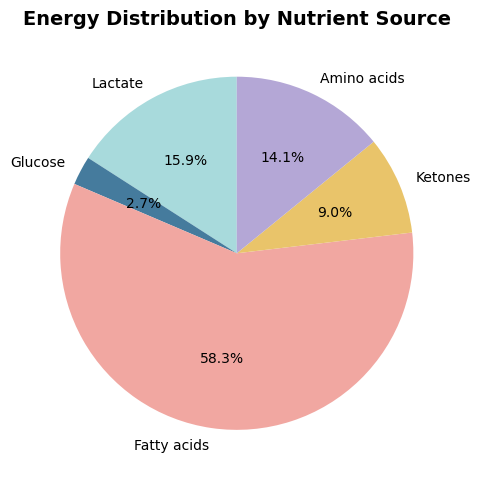

In [16]:
# Pie chart of energy distribution
f, ax = plt.subplots(figsize=(5, 5))
colors = ['#A8DADC', '#457B9D', '#F1A7A1', '#E9C46A', '#B4A7D6']

ax.pie(
    energy_contributions.values(),
    labels=energy_contributions.keys(),
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

ax.set_title('Energy Distribution by Nutrient Source', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

CO2 Contributions (nmolC/min/gBW):
  Lactate        :   318.39 ( 19.6%)
  Glucose        :    13.05 (  0.8%)
  Fatty acids    :   863.70 ( 53.3%)
  Ketones        :   160.11 (  9.9%)
  Amino acids    :   265.15 ( 16.4%)
  Total          :  1620.41


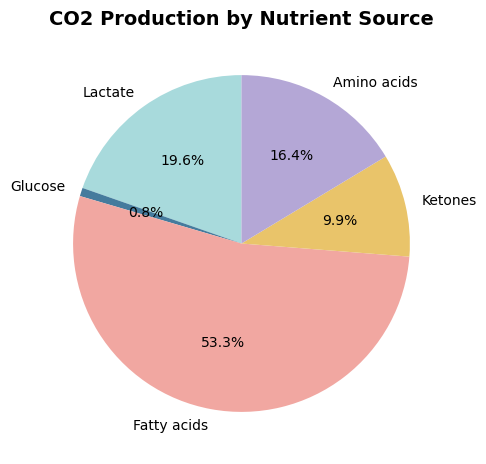

In [17]:
# CO2 contributions from different sources
from multi_nutrient_model_ext import cAA

CO2_from_core = {
    'Lactate': 3 * vL * vE,
    'Glucose': 6 * vG * vE,
    'Fatty acids': 16 * vF * vE,
    'Ketones': 4 * vK * vE,
}

CO2_from_AA = sum(cAA[aa] * vOx[aa] * vE for aa in AMINO_ACIDS)
CO2_contributions = {**CO2_from_core, 'Amino acids': CO2_from_AA}

total_CO2 = sum(CO2_contributions.values())

print("CO2 Contributions (nmolC/min/gBW):")
for source, co2 in CO2_contributions.items():
    percentage = 100 * co2 / total_CO2
    print(f"  {source:15s}: {co2:8.2f} ({percentage:5.1f}%)")
print(f"  {'Total':15s}: {total_CO2:8.2f}")

# Pie chart of CO2 distribution
f, ax = plt.subplots(figsize=(5, 5))
colors_co2 = ['#A8DADC', '#457B9D', '#F1A7A1', '#E9C46A', '#B4A7D6']

ax.pie(
    CO2_contributions.values(),
    labels=CO2_contributions.keys(),
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_co2
)

ax.set_title('CO2 Production by Nutrient Source', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Amino Acid Flux Analysis

In [18]:
# Create dataframe of amino acid fluxes
from multi_nutrient_model_ext import cAA

aa_data = []
for aa in AMINO_ACIDS:
    aa_data.append({
        'AA': aa,
        'Composition (%)': protein_composition[aa] * 100,
        'Oxidation (nmol/min/gBW)': vOx[aa] * vE,
        'Oxidation (nmolC/min/gBW)': vOx[aa] * vE * cAA[aa],
        'From PD (nmol/min/gBW)': protein_composition[aa] * vPD * vE,
        'To PS (nmol/min/gBW)': protein_composition[aa] * vPS * vE,
    })

df_aa = pd.DataFrame(aa_data)
df_aa = df_aa.sort_values('Oxidation (nmolC/min/gBW)', ascending=False)
print(df_aa.to_string(index=False))


 AA  Composition (%)  Oxidation (nmol/min/gBW)  Oxidation (nmolC/min/gBW)  From PD (nmol/min/gBW)  To PS (nmol/min/gBW)
Gln          4.59721                  9.567039                  47.835197                7.939426              4.878580
Leu          7.80186                  5.194518                  31.167109               13.473888              8.279370
Lys          6.69661                  4.458637                  26.751822               11.565110              7.106473
Phe          3.38044                  2.250714                  20.256427                5.838053              3.587339
Val          6.00320                  3.996961                  19.984806               10.367585              6.370624
Arg          4.82851                  3.214847                  19.289079                8.338884              5.124037
Ala          8.52340                  6.079113                  18.237340               14.719994              9.045071
Ile          3.81187                  2.

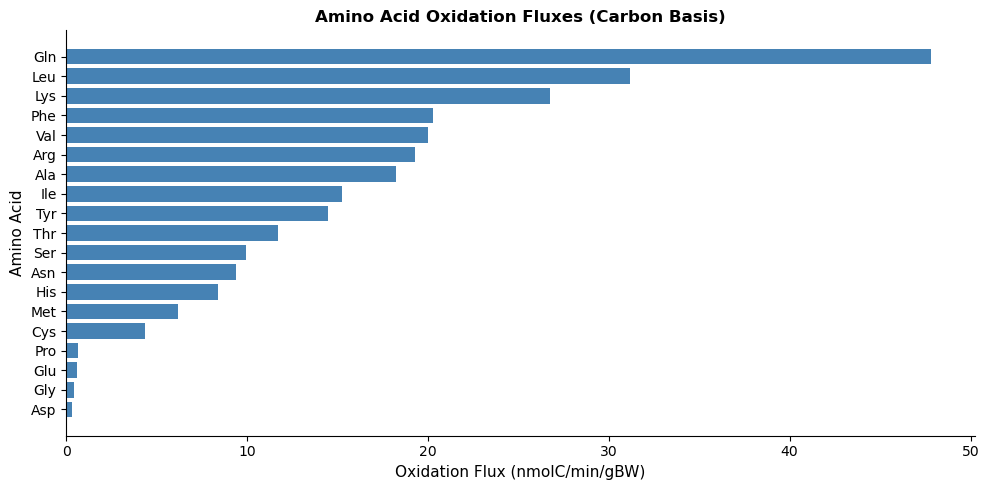

In [19]:
# Bar plot of amino acid oxidation fluxes
f, ax = plt.subplots(figsize=(10, 5))
df_aa_sorted = df_aa.sort_values('Oxidation (nmolC/min/gBW)', ascending=True)

ax.barh(df_aa_sorted['AA'], df_aa_sorted['Oxidation (nmolC/min/gBW)'], color='steelblue')
ax.set_xlabel('Oxidation Flux (nmolC/min/gBW)', fontsize=11)
ax.set_ylabel('Amino Acid', fontsize=11)
ax.set_title('Amino Acid Oxidation Fluxes (Carbon Basis)', fontsize=12, fontweight='bold')
plt.tight_layout()
sns.despine()
plt.show()


In [20]:
total_GNG = v0 + 1/2* vLip  + vLG + 1/2*v_GNG_Gln + 1/2*v_GNG_Ala

# Print gluconeogenic contribution from ala and gln
print(f"Gluconeogenesis from Alanine: {0.5 * v_GNG_Ala * vE:.2f} \
      nmol/min/gBW ({100 * (0.5 * v_GNG_Ala * vE) / (total_GNG * vE):.1f}%)")
print(f"Gluconeogenesis from Glutamine: {0.5 * v_GNG_Gln * vE:.2f} \
      nmol/min/gBW ({100 * (0.5 * v_GNG_Gln * vE) / (total_GNG * vE):.1f}%)")

Gluconeogenesis from Alanine: 5.33       nmol/min/gBW (4.3%)
Gluconeogenesis from Glutamine: 11.73       nmol/min/gBW (9.6%)


In [21]:
# Glutamate oxidation flux
print(f"Glutamate oxidation: {vOx['Glu']}")

Glutamate oxidation: 1.1667729354695905e-05


Nitrogen from AA oxidation: 55.72 nmolN/min/gBW
  Recycled locally: 55.72 nmolN/min/gBW (100.0%)
    vN_Glu_Gln (Glu→Gln): 4.38
    vN_Asp_Gln (Asp→Gln): 3.11
    vN_Pro_Gln (Pro→Gln): 5.05
    vN_Gly_Gln (Gly→Gln): 8.42
    vN_Lac_Gln (2Lac→Gln): 18.02
    vN_Lac_Ala (Lac→Ala): 16.74

Nitrogen exported via gluconeogenesis:
  From AA gluconeogenesis: 57.58 nmolN/min/gBW
    Gln→Glc: 46.93
    Ala→Glc: 10.65

Total nitrogen balance:
  Input (oxidation): 55.72
  Output (recycling only): 55.72
  Balance: 7.11e-15


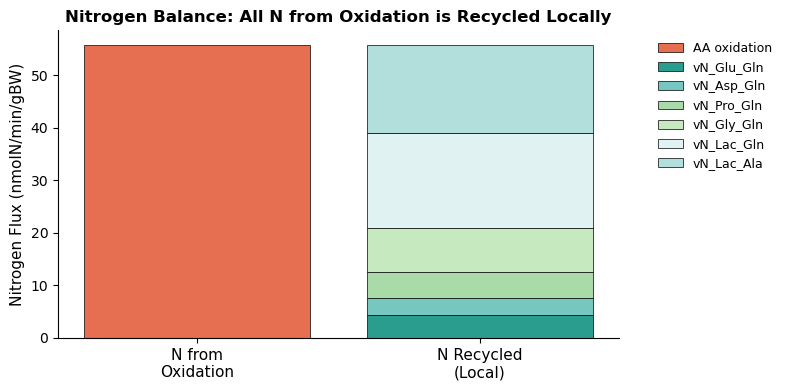

In [22]:
# Nitrogen handling fluxes
from multi_nutrient_model_ext import nNAA

# Calculate nitrogen fluxes from oxidation
# All nitrogen from amino acid oxidation is recycled locally (no direct ammonia excretion)
N_from_oxidation = sum(nNAA[aa] * vOx[aa] * vE for aa in AMINO_ACIDS)

# Nitrogen from gluconeogenesis (exported directly)
N_from_GNG = 2 * v_GNG_Gln * vE + 1 * v_GNG_Ala * vE

# Nitrogen recycling fluxes
N_recycled_Glu_Gln = vN_Glu_Gln * vE  # Glu + N → Gln
N_recycled_Asp_Gln = vN_Asp_Gln * vE  # Asp + N → Gln
N_recycled_Pro_Gln = vN_Pro_Gln * vE  # Pro + N → Gln
N_recycled_Gly_Gln = vN_Gly_Gln * vE  # Gly + N → Gln
N_recycled_Lac_Gln = 2 * vN_Lac_Gln * vE  # 2Lac + 2N → Gln
N_recycled_Lac_Ala = vN_Lac_Ala * vE  # Lac + N → Ala

# Total nitrogen recycled
N_total_recycled = (N_recycled_Glu_Gln + N_recycled_Asp_Gln + N_recycled_Pro_Gln + 
                   N_recycled_Gly_Gln + N_recycled_Lac_Gln + N_recycled_Lac_Ala)

print(f"Nitrogen from AA oxidation: {N_from_oxidation:.2f} nmolN/min/gBW")
print(f"  Recycled locally: {N_total_recycled:.2f} nmolN/min/gBW ({100*N_total_recycled/N_from_oxidation:.1f}%)")
print(f"    vN_Glu_Gln (Glu→Gln): {N_recycled_Glu_Gln:.2f}")
print(f"    vN_Asp_Gln (Asp→Gln): {N_recycled_Asp_Gln:.2f}")
print(f"    vN_Pro_Gln (Pro→Gln): {N_recycled_Pro_Gln:.2f}")
print(f"    vN_Gly_Gln (Gly→Gln): {N_recycled_Gly_Gln:.2f}")
print(f"    vN_Lac_Gln (2Lac→Gln): {N_recycled_Lac_Gln:.2f}")
print(f"    vN_Lac_Ala (Lac→Ala): {N_recycled_Lac_Ala:.2f}")

print(f"\nNitrogen exported via gluconeogenesis:")
print(f"  From AA gluconeogenesis: {N_from_GNG:.2f} nmolN/min/gBW")
print(f"    Gln→Glc: {2 * v_GNG_Gln * vE:.2f}")
print(f"    Ala→Glc: {1 * v_GNG_Ala * vE:.2f}")

print(f"\nTotal nitrogen balance:")
print(f"  Input (oxidation): {N_from_oxidation:.2f}")
print(f"  Output (recycling only): {N_total_recycled:.2f}")
print(f"  Balance: {N_from_oxidation - N_total_recycled:.2e}")

# Stacked bar plot with 2 bars
f, ax = plt.subplots(figsize=(8, 4))

# Bar 1: Nitrogen from oxidation (source)
N_oxidation_data = [N_from_oxidation]
labels_oxidation = ['AA oxidation']
colors_oxidation = ['#E76F51']

# Bar 2: Nitrogen recycling pathways
N_recycling_data = [N_recycled_Glu_Gln, N_recycled_Asp_Gln, N_recycled_Pro_Gln, 
                    N_recycled_Gly_Gln, N_recycled_Lac_Gln, N_recycled_Lac_Ala]
labels_recycling = ['vN_Glu_Gln', 'vN_Asp_Gln', 'vN_Pro_Gln', 
                   'vN_Gly_Gln', 'vN_Lac_Gln', 'vN_Lac_Ala']
colors_recycling = ['#2A9D8F', '#76C7C0', '#A8DBA8', '#C7E9C0', '#E0F2F1', '#B2DFDB']

# Bar 1: Source
ax.bar(0, N_oxidation_data[0], color=colors_oxidation[0], label=labels_oxidation[0], 
       edgecolor='black', linewidth=0.5)

# Bar 2: Local recycling
bottom = 0
for val, label, color in zip(N_recycling_data, labels_recycling, colors_recycling):
    ax.bar(1, val, bottom=bottom, color=color, label=label, edgecolor='black', linewidth=0.5)
    bottom += val

ax.set_xticks([0, 1])
ax.set_xticklabels(['N from\nOxidation', 'N Recycled\n(Local)'], fontsize=11)
ax.set_ylabel('Nitrogen Flux (nmolN/min/gBW)', fontsize=11)
ax.set_title('Nitrogen Balance: All N from Oxidation is Recycled Locally', fontsize=12, fontweight='bold')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


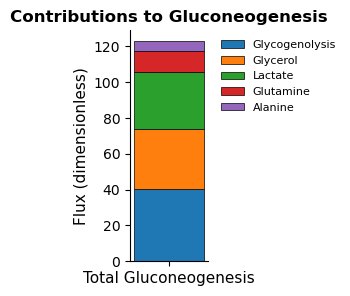

In [23]:
# Contribution to GLucose production from Lac, Ala, Gln and GLycerol (from lipolysis)

# Plot as stacked bar chart
f, ax = plt.subplots(figsize=(1, 3))
components = {
    'Glycogenolysis': v0 * vE,
    'Glycerol': 0.5 * vLip * vE,
    'Lactate': vLG * vE,
    'Glutamine': 0.5 * v_GNG_Gln * vE,
    'Alanine': 0.5 * v_GNG_Ala * vE,
}
bottom = 0
colors_gng = ['#A8DADC', '#457B9D', '#F1A7A1', '#E9C46A', '#B4A7D6']

for label, value in components.items():
    ax.bar(0, value, bottom=bottom, label=label, edgecolor='black', linewidth=0.5)
    bottom += value
ax.set_xticks([0])
ax.set_xticklabels(['Total Gluconeogenesis'], fontsize=11)
ax.set_ylabel('Flux (dimensionless)', fontsize=11)

ax.set_title('Contributions to Gluconeogenesis', fontsize=12, fontweight='bold')

# Legend
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, frameon=False)
sns.despine()
plt.tight_layout()


In [24]:
# Circulatory fluxes (appearance rates)
# Compute appearance rates based on mass balances
vE = vATP

circulatory_fluxes = {
    'Glucose': vGL * vE + vG * vE + 0.5 * vLip * vE,
    'Lactate': 2 * vLG * vE + vL * vE + vN_Lac_Ala * vE + vN_Lac_Gln * vE * 5/3,
    'Fatty acids': vFK * vE + vF * vE + 3 * vReest * vE,
    'Ketones': vK * vE,
}

# Add amino acids
for aa in AMINO_ACIDS:
    circulatory_fluxes[aa] = vPD * vE * protein_composition[aa]

# Add special amino acids with nitrogen recycling
circulatory_fluxes['Ala'] += vN_Lac_Ala * vE
circulatory_fluxes['Gln'] += (vN_Glu_Gln + vN_Asp_Gln + vN_Pro_Gln + vN_Gly_Gln + vN_Lac_Gln) * vE
circulatory_fluxes['Glu'] -= vN_Glu_Gln * vE
circulatory_fluxes['Asp'] -= vN_Asp_Gln * vE
circulatory_fluxes['Pro'] -= vN_Pro_Gln * vE
circulatory_fluxes['Gly'] -= vN_Gly_Gln * vE


# Split fatty acids into C16:0 , C18:1 , C18:2 for representation
# Assume 0.2, 0.3, 0.3 fractions respectively
fa_total = circulatory_fluxes['Fatty acids']
circulatory_fluxes['C16:0'] = fa_total * 0.15
circulatory_fluxes['C18:1'] = fa_total * 0.2
circulatory_fluxes['C18:2'] = fa_total * 0.3

circulatory_fluxes['3-hydroxybutyrate'] = circulatory_fluxes['Ketones'] * 0.6

del circulatory_fluxes['Fatty acids']
del circulatory_fluxes['Ketones']

In [25]:


# Load experimental data from fcirc.csv
fcirc = pd.read_csv('data/fcirc.csv', sep='\t')

# Drop empty columns (file has trailing tabs creating empty columns)
fcirc = fcirc.dropna(axis=1, how='all')

# Ensure we have the expected columns
if len(fcirc.columns) == 4:
    fcirc.columns = ['Metabolite', 'MEAN', 'SEM', 'N']

# Map metabolite names to model names
metabolite_map = {
    'Lactate': 'Lactate',
    'Glucose': 'Glucose',
    'Glycerol': 'Glycerol',
    'Linoleate': 'C18:2',
    'Glutamine': 'Gln',
    'Acetate': 'Acetate',
    'Oleate': 'C18:1',
    '3-hydroxybutyrate': '3-hydroxybutyrate',
    'Alanine': 'Ala',
    'Palmitate': 'C16:0',
    'Glycine': 'Gly',
    'Serine': 'Ser',
    'Lysine': 'Lys',
    'Leucine': 'Leu',
    'Valine': 'Val',
    'Taurine': 'Taurine',
    'Isoleucine': 'Ile',
    'Threonine': 'Thr',
    'Tyrosine': 'Tyr',
    'Citrate': 'Citrate',
    'Proline': 'Pro',
    'Phenylalanine': 'Phe',
    'Methionine': 'Met',
    'Arginine': 'Arg',
    'Glutamate': 'Glu',
    'a-ketoglutarate': 'a-ketoglutarate',
    'Asparagine': 'Asn',
    'Aspartate': 'Asp',
    'Tryptophan': 'Trp',
    'Succinate': 'Succinate',
    'Histidine': 'His',
    'Creatine': 'Creatine',
    'Malate': 'Malate',
}

fcirc['Model_Name'] = fcirc['Metabolite'].map(metabolite_map)
fcirc = fcirc.dropna(subset=['Model_Name'])

# Create experimental data lookup
fcirc_lookup = fcirc.set_index('Model_Name')[['MEAN', 'SEM']].to_dict('index')

# Build comparison dataframe with model predictions and experimental data (where available)
comparison_data = []
for metabolite in circulatory_fluxes.keys():
    row = {
        'Metabolite': metabolite,
        'Model': circulatory_fluxes[metabolite],
        'Experimental': None,
        'SEM': None,
        'Color': '#457B9D' if metabolite in ['Glucose', 'Lactate', '3-hydroxybutyrate', 'C16:0', 'C18:1', 'C18:2','Gln','Ala'] else '#76C7C0'
    }
    
    # Add experimental data if available
    if metabolite in fcirc_lookup:
        row['Experimental'] = fcirc_lookup[metabolite]['MEAN']
        row['SEM'] = fcirc_lookup[metabolite]['SEM']
    
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)

# Sort by experimental data (descending), putting NaN values at the end
comparison_df['Sort_Key'] = comparison_df['Experimental'].fillna(-1)
comparison_df = comparison_df.sort_values('Sort_Key', ascending=False)
comparison_df = comparison_df.drop('Sort_Key', axis=1)

# Display top fluxes
print("Top 20 circulatory fluxes comparison (sorted by experimental data):")
print(comparison_df.head(20).to_string(index=False))


Top 20 circulatory fluxes comparison (sorted by experimental data):
       Metabolite      Model  Experimental   SEM   Color
          Lactate 201.705902        151.70 10.17 #457B9D
          Glucose 133.474178         95.41  4.36 #457B9D
            C18:2  59.923035         47.76  4.62 #457B9D
              Gln  37.911864         37.89  1.16 #457B9D
            C18:1  39.948690         29.48  0.66 #457B9D
3-hydroxybutyrate  24.016870         27.49  1.97 #457B9D
              Ala  31.464786         24.02  1.46 #457B9D
            C16:0  29.961517         23.96  2.03 #457B9D
              Gly  13.997103         13.79  0.54 #76C7C0
              Ser   8.600819         11.31  0.21 #76C7C0
              Lys  11.565110         10.16  0.89 #76C7C0
              Leu  13.473888          9.93  0.64 #76C7C0
              Val  10.367585          9.89  0.32 #76C7C0
              Ile   6.583136          7.57  0.52 #76C7C0
              Thr   7.587824          6.02  0.45 #76C7C0
              Tyr   

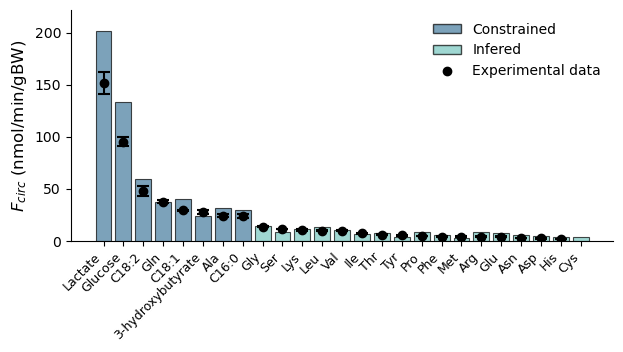


Showing 25 metabolites
Experimental data available for 24 metabolites


In [26]:
# Create circulatory flux comparison plot
fig, ax = plt.subplots(figsize=(7, 3))

# Prepare data for plotting
metabolites = comparison_df['Metabolite'].tolist()
model_fluxes = comparison_df['Model'].tolist()
exp_fluxes = comparison_df['Experimental'].tolist()
exp_errors = comparison_df['SEM'].tolist()
colors = comparison_df['Color'].tolist()

x_positions = np.arange(len(metabolites))

# Plot model predictions as bars
ax.bar(x_positions, model_fluxes, color=colors, edgecolor='black', 
       linewidth=0.8, alpha=0.7)

# Overlay experimental data points with error bars
# Only plot where experimental data exists
exp_x = []
exp_y = []
exp_err = []

for i, (exp_val, sem) in enumerate(zip(exp_fluxes, exp_errors)):
    if exp_val is not None and not np.isnan(exp_val):
        exp_x.append(i)
        exp_y.append(exp_val)
        exp_err.append(sem if sem is not None and not np.isnan(sem) else 0)

# Plot experimental points with error bars
ax.errorbar(exp_x, exp_y, yerr=exp_err, fmt='o', color='black', 
            markersize=6, capsize=4, capthick=1.5, linewidth=1.5,
            zorder=10)

# Formatting
ax.set_ylabel('$F_{circ}$ (nmol/min/gBW)', fontsize=12,)
ax.set_xticks(x_positions)
ax.set_xticklabels(metabolites, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, max(model_fluxes) * 1.1)

# Create custom legend entries for bar colors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='#457B9D', edgecolor='black', alpha=0.7, label='Constrained'),
    Patch(facecolor='#76C7C0', edgecolor='black', alpha=0.7, label='Infered'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
           markersize=6, label='Experimental data', markeredgecolor='black')
]

# Legend
ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=False)

sns.despine()
plt.show()

print(f"\nShowing {len(metabolites)} metabolites")
print(f"Experimental data available for {len(exp_x)} metabolites")
